In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
COLOR_MODE = "rgb"

In [ ]:
# 1 thư viện
import kagglehub
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# Khởi tạo GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


In [ ]:
# Tải dataset trực tiếp từ Kaggle về Colab
print("Đang tải dataset bằng kagglehub...")
dataset_path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print(f"Đã tải xong! Dữ liệu gốc nằm tại: {dataset_path}")

Đang tải dataset bằng kagglehub...
Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Đã tải xong! Dữ liệu gốc nằm tại: /kaggle/input/new-plant-diseases-dataset


In [ ]:
# 2. TỰ ĐỘNG DÒ TÌM ĐƯỜNG DẪN TRAIN / VALID
train_dir = None
val_dir = None

print("Đang tự động dò tìm cấu trúc thư mục...")
for root, dirs, files in os.walk(dataset_path):
    if 'train' in dirs and 'valid' in dirs:
        train_dir = os.path.join(root, 'train')
        val_dir = os.path.join(root, 'valid')
        break

if train_dir is None or val_dir is None:
    raise FileNotFoundError("Lỗi: Không tìm thấy thư mục 'train' và 'valid' bên trong dataset đã tải!")
else:
    print(f"Đã tìm thấy tập Train: {train_dir}")
    print(f"Đã tìm thấy tập Validation: {val_dir}")

# 3. CHUẨN BỊ DỮ LIỆU VÀ DATALOADER
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
print(f"Số lượng classes: {len(class_names)}")

# 4. KHỞI TẠO MÔ HÌNH RESNET-50
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 5. VÒNG LẶP HUẤN LUYỆN
num_epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

since = time.time()

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc)
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc)

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

time_elapsed = time.time() - since
print(f'\nHuấn luyện hoàn tất trong {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Độ chính xác tốt nhất trên tập Validation: {best_acc:4f}')

# 6. LƯU MÔ HÌNH VÀ VẼ BIỂU ĐỒ
model.load_state_dict(best_model_wts)
save_path = '/content/best_resnet_plant.pth'
torch.save(model.state_dict(), save_path)
print(f"Đã lưu mô hình tốt nhất tại: {save_path}")



Đang tự động dò tìm cấu trúc thư mục...
Đã tìm thấy tập Train: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Đã tìm thấy tập Validation: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Số lượng classes: 38

Epoch 1/10
----------
Train Loss: 0.1527 Acc: 0.9616
Val Loss: 0.0228 Acc: 0.9934

Epoch 2/10
----------
Train Loss: 0.0418 Acc: 0.9871
Val Loss: 0.0211 Acc: 0.9929

Epoch 3/10
----------
Train Loss: 0.0333 Acc: 0.9896
Val Loss: 0.0333 Acc: 0.9910

Epoch 4/10
----------
Train Loss: 0.0252 Acc: 0.9925
Val Loss: 0.0412 Acc: 0.9881

Epoch 5/10
----------
Train Loss: 0.0227 Acc: 0.9930
Val Loss: 0.0187 Acc: 0.9937

Epoch 6/10
----------
Train Loss: 0.0165 Acc: 0.9949
Val Loss: 0.0119 Acc: 0.9962

Epoch 7/10
----------
Train Loss: 0.0177 Acc: 0.9944
Val Loss: 0.0176 Acc: 0.9939

Epoch 8/10
----------
Train Loss: 0.0136 Acc: 0.9959
Val Los

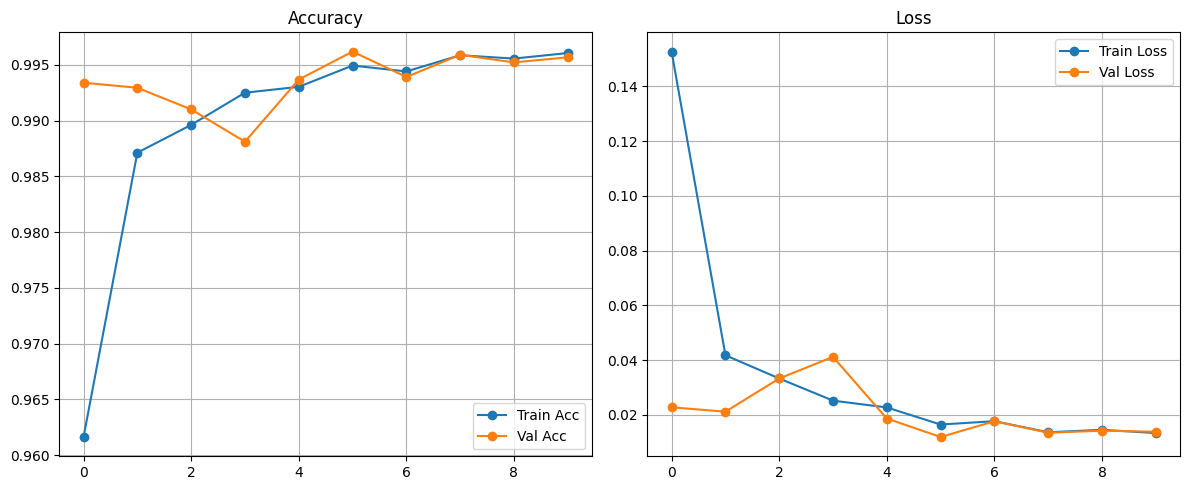

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc', marker='o')
plt.plot(history['val_acc'], label='Val Acc', marker='o')
plt.title('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Đang chạy suy luận (inference) trên tập Validation để lấy kết quả...
Đã lấy xong kết quả! Đang tiến hành vẽ biểu đồ...


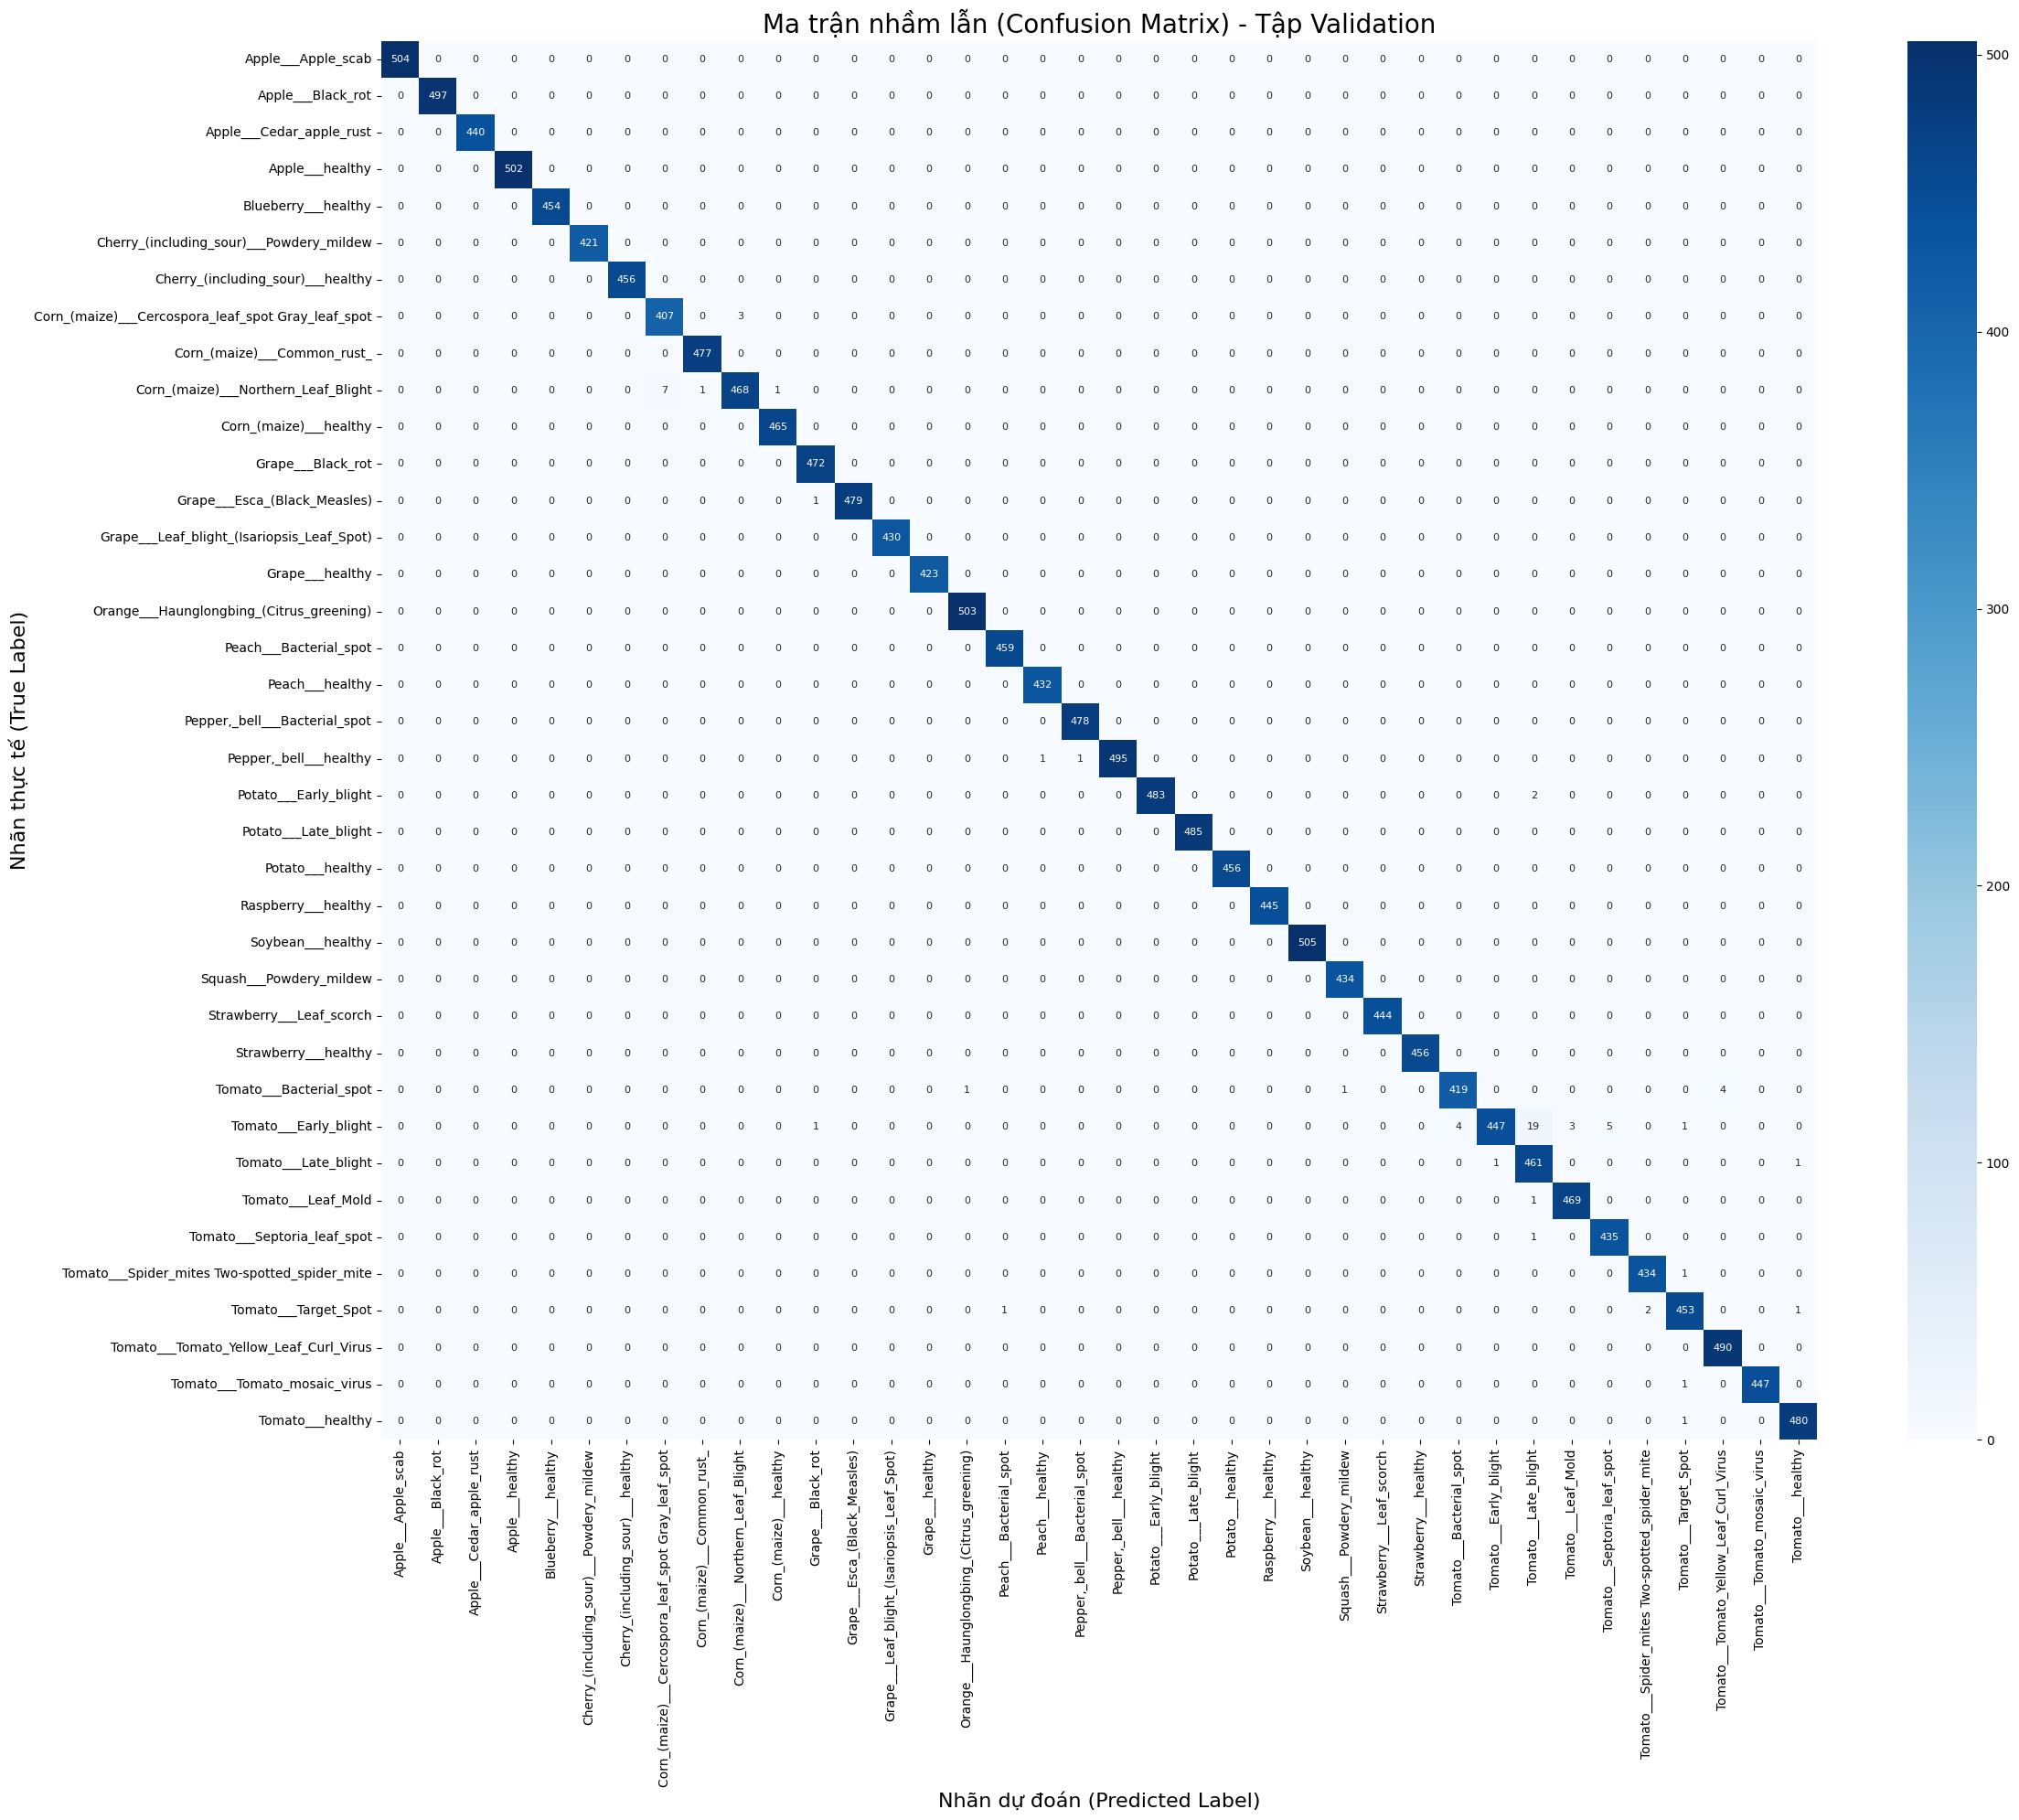

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. THU THẬP NHÃN THỰC TẾ VÀ NHÃN DỰ ĐOÁN
model.eval() # Đảm bảo mô hình ở chế độ đánh giá (không cập nhật trọng số)

y_true = []
y_pred = []

print("Đang chạy suy luận (inference) trên tập Validation để lấy kết quả...")

# Tắt tính toán gradient để tăng tốc và tiết kiệm VRAM
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        # Chuyển tensor từ GPU về CPU và biến thành danh sách (list)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Đã lấy xong kết quả! Đang tiến hành vẽ biểu đồ...")

# 2. TÍNH TOÁN MA TRẬN NHẦM LẪN
cm = confusion_matrix(y_true, y_pred)

# 3. VẼ BIỂU ĐỒ TRỰC QUAN BẰNG SEABORN
plt.figure(figsize=(24, 20)) # Cài đặt khung hình lớn để chứa đủ 38 class

# Sử dụng heatmap để trực quan hóa, fmt='d' để hiển thị số nguyên
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={"size": 8}) # Chỉnh cỡ chữ số bên trong ô nhỏ lại một chút

plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Tập Validation', fontsize=20)
plt.ylabel('Nhãn thực tế (True Label)', fontsize=16)
plt.xlabel('Nhãn dự đoán (Predicted Label)', fontsize=16)

# Xoay chữ ở trục X đi 90 độ để các tên bệnh không bị đè lên nhau
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()